# Laboratorio 03: Regresión Polinómica

## Predicción de la Temperatura Crítica de Superconductore

## 1. Importacioens y Google Drive


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## 2. Carga del Dataset

In [2]:
# Ruta del dataset
ruta = '/content/gdrive/MyDrive/Inteligencia Artificial 1 - Kevin/Laboratorios/Laboratorio 03 - Regresion Polinomica/dataset/train.csv'

# Cargar dataset
df = pd.read_csv(ruta)

print("Dimensiones del dataset:", df.shape)
print("Cantidad de ejemplos (m):", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

df.head()

Dimensiones del dataset: (21263, 82)
Cantidad de ejemplos (m): 21263
Cantidad de columnas: 82


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## 3. Exploracion y analisis del Datasest

Tipos de datos:
float64    79
int64       3
Name: count, dtype: int64

Valores nulos totales: 0

Estadísticas de la variable objetivo:
count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

10 características con mayor relación con critical_temp:
wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_mean_Valence              -0.632401
wtd_entropy_atomic_mass        0.626930
wtd_gmean_Valence             -0.615653
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
Name: critical_temp, dtype: float64

Característica seleccionada: wtd_std_ThermalConductivity
Correlación: 0.7212710791834787


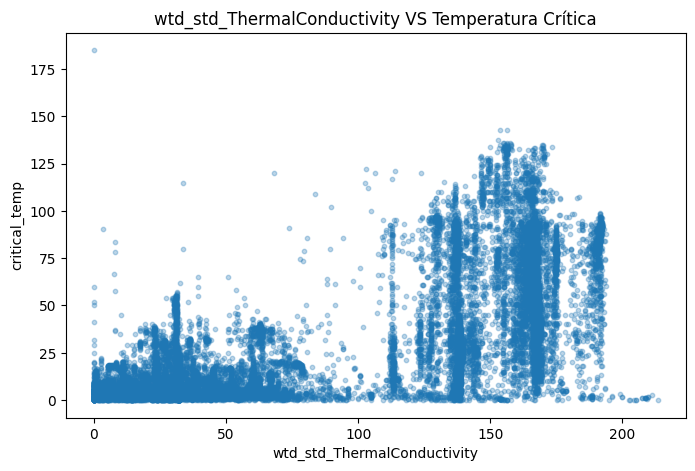

In [4]:
# Información general
print("Tipos de datos:")
print(df.dtypes.value_counts())

print("\nValores nulos totales:", df.isnull().sum().sum())

print("\nEstadísticas de la variable objetivo:")
print(df['critical_temp'].describe())

# Correlación de cada característica con la temperatura crítica
correlaciones = df.corr(numeric_only=True)['critical_temp'].drop('critical_temp')
correlaciones = correlaciones.reindex(
    correlaciones.abs().sort_values(ascending=False).index
)

print("\n10 características con mayor relación con critical_temp:")
print(correlaciones.head(10))

# Característica con mayor correlación
mejor_caracteristica = correlaciones.index[0]

print("\nCaracterística seleccionada:", mejor_caracteristica)
print("Correlación:", correlaciones.iloc[0])


# Gráfica de relación
plt.figure(figsize=(8, 5))
plt.scatter(
    df[mejor_caracteristica],
    df['critical_temp'],
    alpha=0.3,
    s=10
)

plt.xlabel(mejor_caracteristica)
plt.ylabel('critical_temp')
plt.title(f'{mejor_caracteristica} VS Temperatura Crítica')
plt.show()

## 4. Preprocesamiento y division de datos

In [8]:
# Seleccionar las 20 características con mayor correlación absoluta
caracteristicas = (
    correlaciones.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# Para la regresión polinómica utilizaremos las 2 más relacionadas
caracteristicas_poly = caracteristicas[:2]

# Datos para regresión lineal multivariable
X = df[caracteristicas].values.astype(float)

# Datos que después utilizaremos para regresión polinómica
X_poly = df[caracteristicas_poly].values.astype(float)

# Variable objetivo
y = df['critical_temp'].values.astype(float)

m = len(y)

print("Características seleccionadas para regresión multivariable:")
for i, columna in enumerate(caracteristicas, 1):
    print(f"{i}. {columna}")

print("\nCaracterísticas para regresión polinómica:")
print(caracteristicas_poly)


# División aleatoria 80% entrenamiento - 20% prueba
np.random.seed(42)
indices = np.random.permutation(m)

limite = int(0.8 * m)

indices_train = indices[:limite]
indices_test = indices[limite:]

X_train = X[indices_train]
X_test = X[indices_test]

X_poly_train = X_poly[indices_train]
X_poly_test = X_poly[indices_test]

y_train = y[indices_train]
y_test = y[indices_test]

print("\n--- División del Dataset ---")
print("Datos de entrenamiento:", len(y_train))
print("Datos de prueba:", len(y_test))
print("Total:", len(y_train) + len(y_test))

Características seleccionadas para regresión multivariable:
1. wtd_std_ThermalConductivity
2. range_ThermalConductivity
3. range_atomic_radius
4. std_ThermalConductivity
5. wtd_mean_Valence
6. wtd_entropy_atomic_mass
7. wtd_gmean_Valence
8. wtd_entropy_atomic_radius
9. number_of_elements
10. range_fie
11. mean_Valence
12. wtd_std_atomic_radius
13. entropy_Valence
14. wtd_entropy_Valence
15. wtd_std_fie
16. gmean_Valence
17. entropy_fie
18. wtd_entropy_FusionHeat
19. std_atomic_radius
20. entropy_atomic_radius

Características para regresión polinómica:
['wtd_std_ThermalConductivity', 'range_ThermalConductivity']

--- División del Dataset ---
Datos de entrenamiento: 17010
Datos de prueba: 4253
Total: 21263


## 5. Normalizacion

In [9]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división por cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


# Normalizar datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Normalizar datos de prueba usando los mismos mu y sigma
X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos para theta_0
X_train_norm = np.concatenate(
    [np.ones((X_train_norm.shape[0], 1)), X_train_norm],
    axis=1
)

X_test_norm = np.concatenate(
    [np.ones((X_test_norm.shape[0], 1)), X_test_norm],
    axis=1
)

print("Dimensión X_train normalizado:", X_train_norm.shape)
print("Dimensión X_test normalizado:", X_test_norm.shape)

Dimensión X_train normalizado: (17010, 21)
Dimensión X_test normalizado: (4253, 21)


## 6. Funciones de costo

In [11]:
def computeCostMulti(X, y, theta):
    m = len(y)

    predicciones = np.dot(X, theta)
    errores = predicciones - y

    J = (1 / (2 * m)) * np.sum(errores ** 2)

    return J

## 7. Descenso por el Gradiente

In [13]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = len(y)

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):

        predicciones = np.dot(X, theta)
        errores = predicciones - y

        theta = theta - (alpha / m) * np.dot(X.T, errores)

        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

Este bloque se encarga únicamente de actualizar los valores de **theta** en cada iteración y guardar cómo va disminuyendo el costo.

## 8. Regresion Lineal Multivariable - Entrenamiento

In [14]:
# Parámetros de entrenamiento
alpha = 0.01
num_iters = 1500

# Inicializar theta en cero
theta = np.zeros(X_train_norm.shape[1])

# Entrenar modelo
theta_lineal, J_history_lineal = gradientDescentMulti(
    X_train_norm,
    y_train,
    theta,
    alpha,
    num_iters
)

print("Entrenamiento completado.")
print("Costo final:", J_history_lineal[-1])

print("\nValores de theta:")
print(theta_lineal)

Entrenamiento completado.
Costo final: 235.38857515124585

Valores de theta:
[34.37456521 14.92588963  2.19855428  9.35656886 -2.58891062 -3.65466579
  8.71463762  1.59207476 -2.17841663  5.79794559  4.21870272 -4.58387647
 -1.30155571 -0.32487522  0.15649143 -6.47217721  1.57283318 -4.53360968
  1.91904447 -2.35260027 -4.88558482]


## 9. Grafica del costo - regresion lineal multivariable

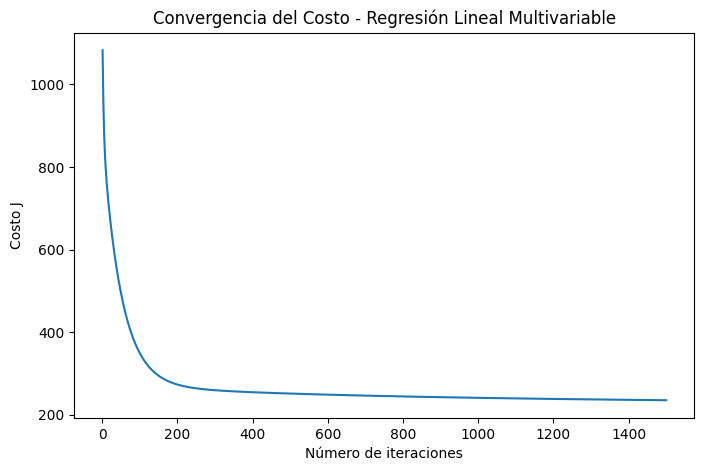

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, num_iters + 1), J_history_lineal)

plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Costo - Regresión Lineal Multivariable')

plt.show()

## 10. Preparacion de la Regresión Polinómica

In [16]:
def crearCaracteristicasPolinomicas(X):
    x1 = X[:, 0]
    x2 = X[:, 1]

    X_poly = np.column_stack([
        x1,
        x2,
        x1**2,
        x1 * x2,
        x2**2
    ])

    return X_poly


# Crear características polinómicas
X_poly_train_g2 = crearCaracteristicasPolinomicas(X_poly_train)
X_poly_test_g2 = crearCaracteristicasPolinomicas(X_poly_test)

print("Características originales:")
print(caracteristicas_poly)

print("\nTérminos polinómicos:")
print("x1, x2, x1², x1*x2, x2²")

print("\nDimensión entrenamiento:", X_poly_train_g2.shape)
print("Dimensión prueba:", X_poly_test_g2.shape)

Características originales:
['wtd_std_ThermalConductivity', 'range_ThermalConductivity']

Términos polinómicos:
x1, x2, x1², x1*x2, x2²

Dimensión entrenamiento: (17010, 5)
Dimensión prueba: (4253, 5)


Estamos pasando de las 2 variables originales a:


## 11. Normalizacion de datos polinómicos

In [17]:
# Normalizar características polinómicas de entrenamiento
X_poly_train_norm, mu_poly, sigma_poly = featureNormalize(X_poly_train_g2)

# Normalizar datos de prueba con los mismos valores
X_poly_test_norm = (X_poly_test_g2 - mu_poly) / sigma_poly

# Agregar columna de unos para theta_0
X_poly_train_norm = np.concatenate(
    [np.ones((X_poly_train_norm.shape[0], 1)), X_poly_train_norm],
    axis=1
)

X_poly_test_norm = np.concatenate(
    [np.ones((X_poly_test_norm.shape[0], 1)), X_poly_test_norm],
    axis=1
)

print("Dimensión X_poly_train normalizado:", X_poly_train_norm.shape)
print("Dimensión X_poly_test normalizado:", X_poly_test_norm.shape)

Dimensión X_poly_train normalizado: (17010, 6)
Dimensión X_poly_test normalizado: (4253, 6)


## 12. Entrenamiento de la Regresion Polinomica

In [18]:
# Parámetros de entrenamiento
alpha_poly = 0.01
num_iters_poly = 1500

# Inicializar theta
theta_poly_inicial = np.zeros(X_poly_train_norm.shape[1])

# Entrenar modelo polinómico
theta_poly, J_history_poly = gradientDescentMulti(
    X_poly_train_norm,
    y_train,
    theta_poly_inicial,
    alpha_poly,
    num_iters_poly
)

print("Entrenamiento polinómico completado.")
print("Costo final:", J_history_poly[-1])

print("\nValores de theta:")
print(theta_poly)

Entrenamiento polinómico completado.
Costo final: 268.1515495116827

Valores de theta:
[34.37456521  4.10330354 -1.94414875 11.91642465  8.64733113  2.39305548]


## 13. Gráfica del costo — regresión polinómica

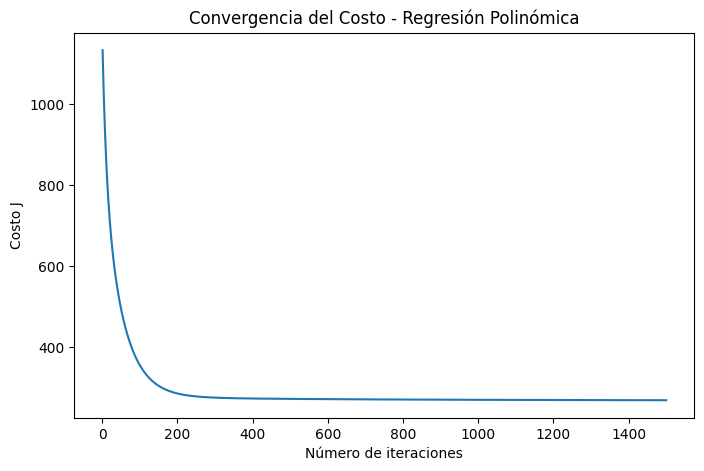

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, num_iters_poly + 1), J_history_poly)

plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Costo - Regresión Polinómica')

plt.show()

## 14. Ecuacion de la Normal

Como la ecuación normal no usa descenso por gradiente ni iteraciones, calculamos directamente los **theta**.

In [20]:
# Calcular theta mediante la Ecuación de la Normal
theta_normal = np.linalg.pinv(
    X_train_norm.T @ X_train_norm
) @ X_train_norm.T @ y_train

# Calcular costo
costo_normal = computeCostMulti(
    X_train_norm,
    y_train,
    theta_normal
)

print("Theta calculado por la Ecuación de la Normal:")
print(theta_normal)

print("\nCosto del modelo:", costo_normal)

Theta calculado por la Ecuación de la Normal:
[ 3.43745750e+01  2.14281878e+01  6.03081091e+00  3.78287945e+01
 -1.42862646e+01 -3.47763390e+01  1.05107342e+01  3.60192363e+01
 -7.12335334e-03 -3.50065659e+00  1.45272996e+01 -1.99632363e+01
  3.68620266e+00 -2.62004218e+01 -6.06896357e+00 -1.42801873e+01
  1.43415448e+01  6.70473562e+01  5.03450432e+00 -3.16071936e+01
 -5.03373183e+01]

Costo del modelo: 216.90857241646117


## 15. Inferencias y Predicciones de los Modelos

In [21]:
# Predicciones sobre el conjunto de prueba
pred_lineal = np.dot(X_test_norm, theta_lineal)
pred_poly = np.dot(X_poly_test_norm, theta_poly)
pred_normal = np.dot(X_test_norm, theta_normal)

# Mostrar 100 predicciones
print(f"{'Real':>12} {'Lineal':>12} {'Polinómica':>12} {'Normal':>12}")
print("-" * 52)

for i in range(100):
    print(
        f"{y_test[i]:12.2f} "
        f"{pred_lineal[i]:12.2f} "
        f"{pred_poly[i]:12.2f} "
        f"{pred_normal[i]:12.2f}"
    )

        Real       Lineal   Polinómica       Normal
----------------------------------------------------
        3.93        21.60        13.98        20.92
        6.50        39.53        38.74        37.92
       82.00        51.50        45.78        56.73
       13.30        40.40        38.73        34.42
        1.02        48.98        87.74        46.03
        6.62        27.12        10.86        24.36
        4.21        21.97         5.52        22.02
       67.50        61.61        63.03        56.34
       54.50        60.21        62.45        58.32
      110.00        68.03        61.34        76.28
       10.70         7.35        11.22        11.80
        6.00         0.62         7.60        -8.24
        4.17        -6.59         5.84         1.25
       30.20        60.91        63.33        55.46
       25.00        39.44        49.58        27.18
       63.70        66.62        60.96        73.46
       41.00        57.90        52.66        54.52
        3.6

## 16. Evaluacion de los Modelos

Aquí sí calculamos MAE, RMSE y R² nosotros mismos con NumPy, sin PyTorch ni sklearn.

In [22]:
# Funciones de evaluación
def calcularMAE(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))


def calcularRMSE(y_real, y_pred):
    return np.sqrt(np.mean((y_real - y_pred) ** 2))


def calcularR2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)

    return 1 - (ss_res / ss_tot)


# Evaluar sobre TODO el conjunto de prueba
mae_lineal = calcularMAE(y_test, pred_lineal)
rmse_lineal = calcularRMSE(y_test, pred_lineal)
r2_lineal = calcularR2(y_test, pred_lineal)

mae_poly = calcularMAE(y_test, pred_poly)
rmse_poly = calcularRMSE(y_test, pred_poly)
r2_poly = calcularR2(y_test, pred_poly)

mae_normal = calcularMAE(y_test, pred_normal)
rmse_normal = calcularRMSE(y_test, pred_normal)
r2_normal = calcularR2(y_test, pred_normal)


print(f"{'Modelo':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 58)

print(f"{'Lineal Multivariable':<25} {mae_lineal:10.2f} {rmse_lineal:10.2f} {r2_lineal:10.4f}")
print(f"{'Regresión Polinómica':<25} {mae_poly:10.2f} {rmse_poly:10.2f} {r2_poly:10.4f}")
print(f"{'Ecuación Normal':<25} {mae_normal:10.2f} {rmse_normal:10.2f} {r2_normal:10.4f}")

Modelo                           MAE       RMSE         R²
----------------------------------------------------------
Lineal Multivariable           16.97      21.70     0.6045
Regresión Polinómica           17.08      23.22     0.5473
Ecuación Normal                16.22      20.79     0.6371


## 17. Comparación Final

Comparación Final de los Modelos


,Modelo,Costo,MAE,RMSE,R²
0,Lineal Multivariable,235.3886,16.9668,21.7042,0.6045
1,Regresión Polinómica,268.1515,17.0788,23.2212,0.5473
2,Ecuación Normal,216.9086,16.2185,20.7913,0.6371


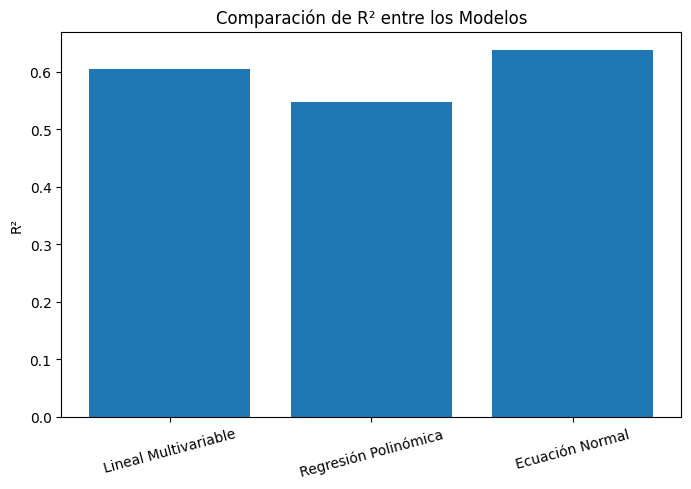

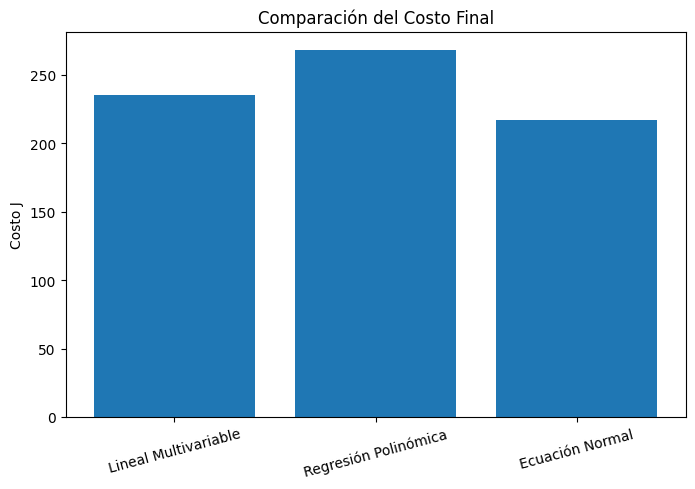

In [23]:
# Tabla comparativa de los tres modelos
resultados = pd.DataFrame({
    'Modelo': [
        'Lineal Multivariable',
        'Regresión Polinómica',
        'Ecuación Normal'
    ],
    'Costo': [
        J_history_lineal[-1],
        J_history_poly[-1],
        costo_normal
    ],
    'MAE': [
        mae_lineal,
        mae_poly,
        mae_normal
    ],
    'RMSE': [
        rmse_lineal,
        rmse_poly,
        rmse_normal
    ],
    'R²': [
        r2_lineal,
        r2_poly,
        r2_normal
    ]
})

print("Comparación Final de los Modelos")
display(resultados.round(4))


# Gráfica de R²
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['R²']
)

plt.ylabel('R²')
plt.title('Comparación de R² entre los Modelos')
plt.xticks(rotation=15)
plt.show()


# Gráfica del costo final
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['Costo']
)

plt.ylabel('Costo J')
plt.title('Comparación del Costo Final')
plt.xticks(rotation=15)
plt.show()